# Calibration Analysis

Computes Expected Calibration Error (ECE) and plots reliability diagrams
for both benchmark tasks (Section 5.1, Figure 2 of the paper):

- **JI** (Jargon Identification): binary A/B task — confidence range [0.5, 1.0]
- **JU** (Jargon Understanding): 5-way MCQ task — confidence range [0.0, 1.0]

Inputs are prediction CSV files produced by `decompose.py` from
[terarachang/LLMDecomp](https://github.com/terarachang/LLMDecomp),
which writes one row per example with columns `logit_A`, `logit_B`, ...
and a `correct` column (1/0).


## Setup

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import softmax

warnings.filterwarnings("ignore")

In [2]:
import os
os.chdir('LLMDecomp')  # or 'LLMDecomp-main' if from zip
print(f"Working directory: {os.getcwd()}")

Working directory: /home-nfs/dkeng/LLMDecomp


In [3]:
# ---------------------------------------------------------------------------
# Paths — update these to match your local LLMDecomp DECOMP output directory
# ---------------------------------------------------------------------------

# JI (Jargon Identification) prediction files
JI_LLAMA_PATH = "DECOMP/meta-llama/Meta-Llama-3.1-8B-Instruct/jargon_detect/0shots/f1/predictions-test-0.csv"
JI_ULTRA_PATH = "DECOMP/TsinghuaC3I/Llama-3.1-8B-UltraMedical/jargon_detect/0shots/f1/predictions-test-0.csv"

# JU (Jargon Understanding) prediction files
JU_LLAMA_PATH = "DECOMP/meta-llama/Meta-Llama-3.1-8B-Instruct/medical_mcq/0shots/f1/predictions-test-0.csv"
JU_ULTRA_PATH = "DECOMP/TsinghuaC3I/Llama-3.1-8B-UltraMedical/medical_mcq/0shots/f1/predictions-test-0.csv"

# Output directory for saved figures
FIG_DIR = "thesis_fig"
os.makedirs(FIG_DIR, exist_ok=True)

# ---------------------------------------------------------------------------
# Shared constants
# ---------------------------------------------------------------------------

N_BINS = 10
CONF_HIST_BINS = 15

COLOR_MEDICAL = "#d4726a"
COLOR_BASE    = "#6a9fd4"
COLOR_DIAG    = "#4a7fbf"

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.6,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
    "axes.edgecolor": "#cccccc",
    "xtick.color": "#555555",
    "ytick.color": "#555555",
    "axes.labelcolor": "#333333",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

## Shared helper functions

`load_and_prepare` and `compute_calibration` are parameterized so they
work for both JI (binary, 2 logit columns) and JU (5-way, 5 logit columns).
The only difference between the two tasks is the confidence bin range:
[0.5, 1.0] for binary (chance = 0.5) and [0.0, 1.0] for 5-way
(chance = 0.2).


In [4]:
def load_and_prepare(path, labels):
    """Load a LLMDecomp predictions CSV and compute derived probability columns.

    Args:
        path:   Path to predictions-test-*.csv from decompose.py.
        labels: List of option letters used by this task, e.g. ['A','B'] for
                JI or ['A','B','C','D','E'] for JU.

    Returns:
        DataFrame with additional columns: max_prob, gold_prob, entropy, margin,
        and prob_{label} for each label.
    """
    logit_cols = [f"logit_{l}" for l in labels]
    df = pd.read_csv(path)
    probs = softmax(df[logit_cols].values, axis=1)

    df["max_prob"]  = probs.max(axis=1)
    df["gold_prob"] = [probs[i, labels.index(g)] for i, g in enumerate(df["gold"])]
    df["entropy"]   = -np.sum(probs * np.log(probs + 1e-12), axis=1)

    sorted_p = np.sort(probs, axis=1)[:, ::-1]
    df["margin"] = sorted_p[:, 0] - sorted_p[:, 1]

    for i, l in enumerate(labels):
        df[f"prob_{l}"] = probs[:, i]

    return df


def compute_calibration(df, n_bins=N_BINS, conf_range=(0.0, 1.0)):
    """Compute ECE and per-bin accuracy/confidence/count.

    Args:
        df:          DataFrame from load_and_prepare().
        n_bins:      Number of equal-width confidence bins.
        conf_range:  (lo, hi) range for binning. Use (0.5, 1.0) for binary
                     tasks (JI) and (0.0, 1.0) for multi-class tasks (JU).

    Returns:
        edges, bin_accs, bin_confs, bin_counts, ece
    """
    confs = df["max_prob"].values
    accs  = df["correct"].values.astype(float)
    edges = np.linspace(conf_range[0], conf_range[1], n_bins + 1)

    bin_accs, bin_confs, bin_counts = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        mask = (confs >= lo) & (confs < hi)
        n = mask.sum()
        if n > 0:
            bin_accs.append(accs[mask].mean())
            bin_confs.append(confs[mask].mean())
        else:
            bin_accs.append(0)
            bin_confs.append((lo + hi) / 2)
        bin_counts.append(n)

    bin_accs   = np.array(bin_accs)
    bin_confs  = np.array(bin_confs)
    bin_counts = np.array(bin_counts)

    valid = bin_counts > 0
    ece = np.sum(bin_counts[valid] * np.abs(bin_confs[valid] - bin_accs[valid])) / len(df)
    return edges, bin_accs, bin_confs, bin_counts, ece


def plot_reliability_diagram(ax, edges, bin_accs, bin_counts, ece, title, color,
                              conf_range=(0.0, 1.0), show_ylabel=True,
                              xticks=None, yticks=None):
    """Draw a reliability diagram (accuracy bars + perfect-calibration diagonal).

    Font sizes follow rcParams (axes.labelsize=12, axes.titlesize=13) for
    axis labels and title. ECE badge uses fontsize=12, matching the reference
    calibration script.

    Args:
        ax:          Matplotlib Axes to draw on.
        edges:       Bin edges from compute_calibration().
        bin_accs:    Per-bin mean accuracy.
        bin_counts:  Per-bin sample count.
        ece:         Expected Calibration Error.
        title:       Plot title (model name).
        color:       Bar and ECE badge color.
        conf_range:  Axis x-limits; should match conf_range used in
                     compute_calibration().
        show_ylabel: Whether to show the y-axis label (set False for
                     right-hand plots to avoid repetition).
        xticks/yticks: Override default tick positions.
    """
    bw = edges[1] - edges[0]
    for i in range(len(bin_accs)):
        if bin_counts[i] > 0:
            ax.bar(edges[i], bin_accs[i], width=bw, align="edge",
                   color=color, alpha=0.55, edgecolor="white",
                   linewidth=0.6, zorder=2)

    ax.plot(list(conf_range), list(conf_range), "--",
            color=COLOR_DIAG, linewidth=1.5, zorder=4)

    ax.text(0.05, 0.92, f"ECE: {ece * 100:.2f}%",
            transform=ax.transAxes, fontsize=12, fontweight="bold",
            color=color,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                      edgecolor=color, alpha=0.85))

    ax.set_xlim(*conf_range)
    ax.set_ylim(0, 1)
    # Note: set_aspect("equal") is intentionally omitted. For the JU task
    # (conf_range [0,1]) the axes are naturally square; for JI (conf_range
    # [0.5,1]) equal aspect would compress the bars horizontally.
    ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Confidence")
    if show_ylabel:
        ax.set_ylabel("Accuracy")
    ax.set_xticks(xticks if xticks is not None else list(np.linspace(*conf_range, 3)))
    ax.set_yticks(yticks if yticks is not None else [0, 0.25, 0.5, 0.75, 1.0])

## JI Calibration (Jargon Identification)

Binary task (A = jargon, B = non-jargon). Confidence range [0.5, 1.0]
since chance performance is 50%.


In [5]:
JI_LABELS = ["A", "B"]

df_ji_base    = load_and_prepare(JI_LLAMA_PATH, JI_LABELS)
df_ji_medical = load_and_prepare(JI_ULTRA_PATH, JI_LABELS)

e_ji_b, ba_ji_b, bc_ji_b, bn_ji_b, ece_ji_b = compute_calibration(df_ji_base,    conf_range=(0.5, 1.0))
e_ji_m, ba_ji_m, bc_ji_m, bn_ji_m, ece_ji_m = compute_calibration(df_ji_medical, conf_range=(0.5, 1.0))

print(f"JI  Base    — acc: {df_ji_base['correct'].mean():.4f}  ECE: {ece_ji_b:.4f}")
print(f"JI  Medical — acc: {df_ji_medical['correct'].mean():.4f}  ECE: {ece_ji_m:.4f}")

JI  Base    — acc: 0.5880  ECE: 0.2913
JI  Medical — acc: 0.5308  ECE: 0.4263


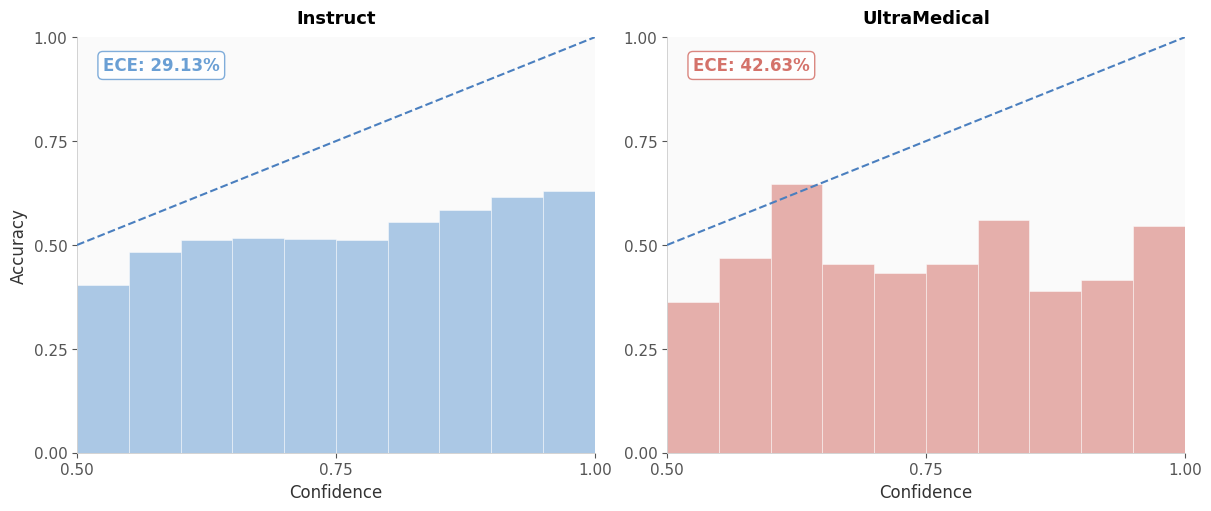

In [6]:
fig_ji, (ax_ji_base, ax_ji_med) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

plot_reliability_diagram(
    ax_ji_base, e_ji_b, ba_ji_b, bn_ji_b, ece_ji_b,
    title="Instruct", color=COLOR_BASE,
    conf_range=(0.5, 1.0),
    xticks=[0.5, 0.75, 1.0], yticks=[0, 0.25, 0.5, 0.75, 1.0],
)
plot_reliability_diagram(
    ax_ji_med, e_ji_m, ba_ji_m, bn_ji_m, ece_ji_m,
    title="UltraMedical", color=COLOR_MEDICAL,
    conf_range=(0.5, 1.0),
    show_ylabel=False,
    xticks=[0.5, 0.75, 1.0], yticks=[0, 0.25, 0.5, 0.75, 1.0],
)

fig_ji.savefig(f"{FIG_DIR}/calibration_curves_onecol_JI.pdf",
               bbox_inches="tight", facecolor="white")
plt.show()

## JU Calibration (Jargon Understanding)

5-way MCQ task (A–E). Confidence range [0.0, 1.0]; chance performance
is 20%.


In [7]:
JU_LABELS = ["A", "B", "C", "D", "E"]

df_ju_base    = load_and_prepare(JU_LLAMA_PATH, JU_LABELS)
df_ju_medical = load_and_prepare(JU_ULTRA_PATH, JU_LABELS)

e_ju_b, ba_ju_b, bc_ju_b, bn_ju_b, ece_ju_b = compute_calibration(df_ju_base,    conf_range=(0.0, 1.0))
e_ju_m, ba_ju_m, bc_ju_m, bn_ju_m, ece_ju_m = compute_calibration(df_ju_medical, conf_range=(0.0, 1.0))

print(f"JU  Base    — acc: {df_ju_base['correct'].mean():.4f}  ECE: {ece_ju_b:.4f}")
print(f"JU  Medical — acc: {df_ju_medical['correct'].mean():.4f}  ECE: {ece_ju_m:.4f}")

JU  Base    — acc: 0.7605  ECE: 0.0228
JU  Medical — acc: 0.7411  ECE: 0.0986


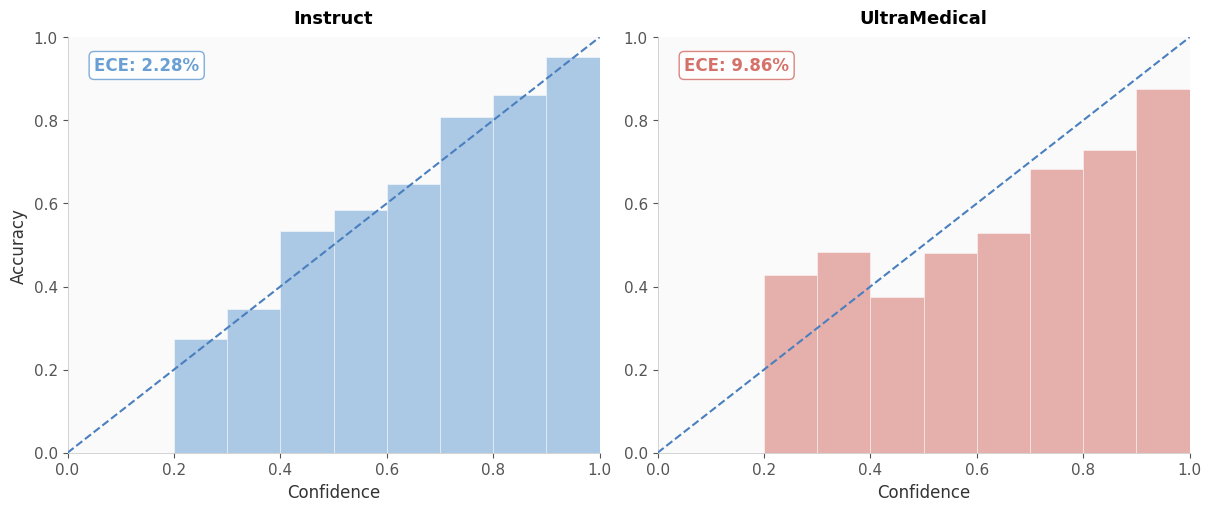

In [8]:
fig_ju, (ax_ju_base, ax_ju_med) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

plot_reliability_diagram(
    ax_ju_base, e_ju_b, ba_ju_b, bn_ju_b, ece_ju_b,
    title="Instruct", color=COLOR_BASE,
    conf_range=(0.0, 1.0),
    xticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0], yticks=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
)
plot_reliability_diagram(
    ax_ju_med, e_ju_m, ba_ju_m, bn_ju_m, ece_ju_m,
    title="UltraMedical", color=COLOR_MEDICAL,
    conf_range=(0.0, 1.0),
    show_ylabel=False,
    xticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0], yticks=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
)

fig_ju.savefig(f"{FIG_DIR}/calibration_curves_JU.pdf",
               bbox_inches="tight", facecolor="white")
plt.show()

## Supplementary: Confidence-when-wrong histograms

Shows the distribution of model confidence on incorrectly answered
examples, for both tasks. Useful for diagnosing overconfidence patterns
(Section 5.1).


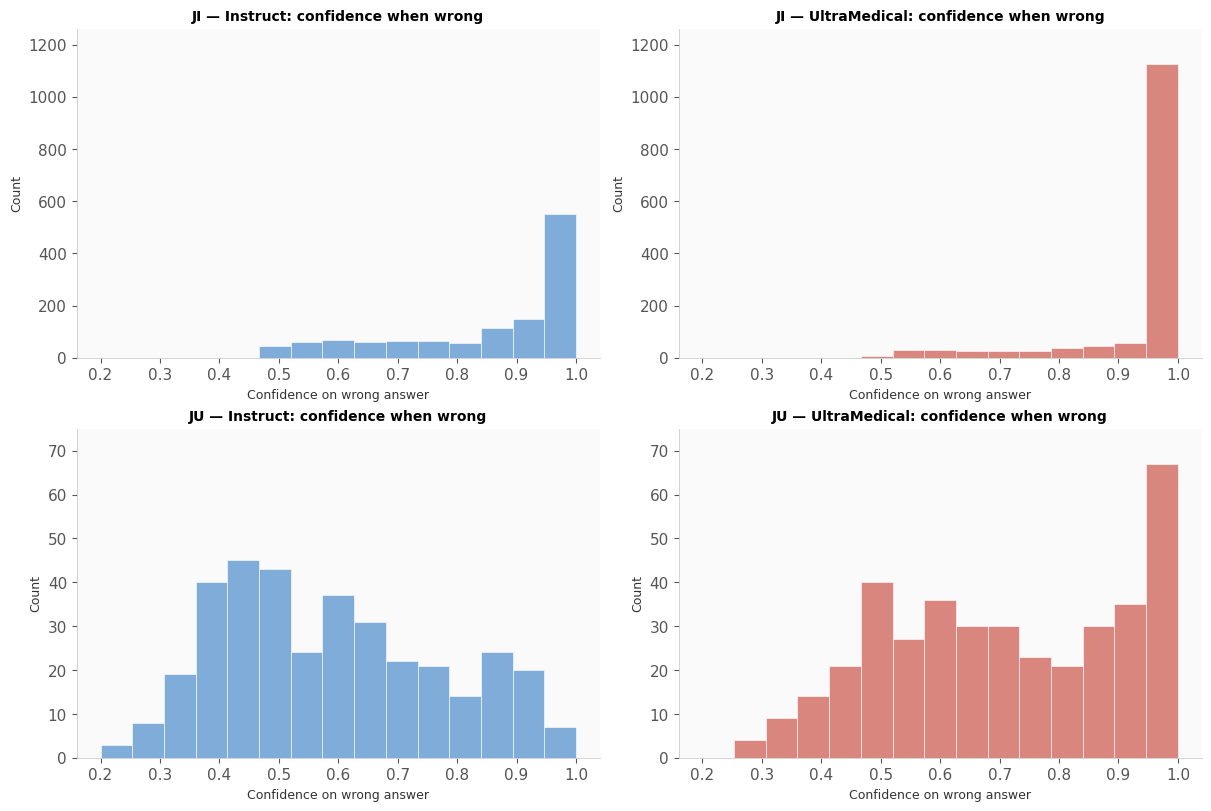

In [9]:
def plot_confidence_histogram(ax, wrong_confs, title, color, hist_bins):
    """Histogram of max_prob values on incorrectly answered examples."""
    ax.hist(wrong_confs, bins=hist_bins, color=color,
            edgecolor="white", linewidth=0.5, alpha=0.85)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_xlabel("Confidence on wrong answer", fontsize=9)
    ax.set_ylabel("Count", fontsize=9)


hist_bins = np.linspace(0.2, 1.0, CONF_HIST_BINS + 1)

fig_hist, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

tasks = [
    ("JI", df_ji_base,    df_ji_medical),
    ("JU", df_ju_base,    df_ju_medical),
]

for row, (task, df_base, df_med) in enumerate(tasks):
    wrong_base = df_base.loc[~df_base["correct"].astype(bool), "max_prob"].values
    wrong_med  = df_med.loc[~df_med["correct"].astype(bool), "max_prob"].values

    plot_confidence_histogram(axes[row, 0], wrong_base,
                              f"{task} — Instruct: confidence when wrong",
                              COLOR_BASE, hist_bins)
    plot_confidence_histogram(axes[row, 1], wrong_med,
                              f"{task} — UltraMedical: confidence when wrong",
                              COLOR_MEDICAL, hist_bins)

    y_max = max(
        np.histogram(wrong_base, bins=hist_bins)[0].max(),
        np.histogram(wrong_med,  bins=hist_bins)[0].max(),
    ) * 1.12
    axes[row, 0].set_ylim(0, y_max)
    axes[row, 1].set_ylim(0, y_max)

fig_hist.savefig(f"{FIG_DIR}/confidence_when_wrong.png",
                 dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Calibration metrics summary

Prints a comparison table of calibration-related statistics for both
models across both tasks, matching Table 1 and Figure 2 of the paper.


In [10]:
def print_calibration_report(task, labels, df_base, df_med, ece_b, ece_m):
    logit_cols = [f"logit_{l}" for l in labels]
    print(f"{'=' * 65}")
    print(f"  {task} CALIBRATION SUMMARY")
    print(f"{'=' * 65}")
    print(f"{'Metric':<40} {'Instruct':>10} {'UltraMedical':>12}")
    print(f"{'-' * 65}")

    rows = [
        ("Accuracy",
         df_base["correct"].mean(),
         df_med["correct"].mean()),
        ("ECE",
         ece_b, ece_m),
        ("Mean confidence",
         df_base["max_prob"].mean(),
         df_med["max_prob"].mean()),
        ("Mean confidence (correct)",
         df_base.loc[df_base["correct"].astype(bool), "max_prob"].mean(),
         df_med.loc[df_med["correct"].astype(bool), "max_prob"].mean()),
        ("Mean confidence (wrong)",
         df_base.loc[~df_base["correct"].astype(bool), "max_prob"].mean(),
         df_med.loc[~df_med["correct"].astype(bool), "max_prob"].mean()),
        ("Mean entropy",
         df_base["entropy"].mean(),
         df_med["entropy"].mean()),
        ("Mean margin (top1 - top2)",
         df_base["margin"].mean(),
         df_med["margin"].mean()),
        ("Mean logit std",
         df_base[logit_cols].values.std(axis=1).mean(),
         df_med[logit_cols].values.std(axis=1).mean()),
    ]

    for label, b_val, m_val in rows:
        print(f"{label:<40} {b_val:>10.4f} {m_val:>12.4f}")

    wrong_b = ~df_base["correct"].astype(bool)
    wrong_m = ~df_med["correct"].astype(bool)
    n_overconf_b = ((wrong_b) & (df_base["max_prob"] > 0.8)).sum()
    n_overconf_m = ((wrong_m) & (df_med["max_prob"]  > 0.8)).sum()
    pct_b = n_overconf_b / wrong_b.sum() * 100
    pct_m = n_overconf_m / wrong_m.sum() * 100

    print(f"{'Wrong + confident (>0.8)':<40} {n_overconf_b:>10} {n_overconf_m:>12}")
    print(f"{'% errors >0.8 conf':<40} {pct_b:>9.1f}% {pct_m:>11.1f}%")
    print()


print_calibration_report("JI", JI_LABELS, df_ji_base, df_ji_medical, ece_ji_b, ece_ji_m)
print_calibration_report("JU", JU_LABELS, df_ju_base, df_ju_medical, ece_ju_b, ece_ju_m)

  JI CALIBRATION SUMMARY
Metric                                     Instruct UltraMedical
-----------------------------------------------------------------
Accuracy                                     0.5880       0.5308
ECE                                          0.2913       0.4263
Mean confidence                              0.8792       0.9565
Mean confidence (correct)                    0.8924       0.9618
Mean confidence (wrong)                      0.8604       0.9505
Mean entropy                                 0.2801       0.0968
Mean margin (top1 - top2)                    0.7585       0.9130
Mean logit std                               1.5000       4.1894
Wrong + confident (>0.8)                        867         1247
% errors >0.8 conf                            70.4%        88.9%

  JU CALIBRATION SUMMARY
Metric                                     Instruct UltraMedical
-----------------------------------------------------------------
Accuracy                             